Notebook AT1 Deep Learning

# COSC2779 Deep Learning — Assessment 1
## Hand Gesture Classification Using 2-D Convolutional Neural Networks

### Problem

The objective of this project is to develop a deep learning classifier capable
of recognising 13 hand-signal gestures. Each gesture instance consists of five
consecutive image frames.

The classifier must use a 2-D convolutional backbone and should make use of
information from all five frames while remaining small enough for plausible
real-time inference on constrained onboard hardware.

# Method for pushing changes to github

cd ~/SageMaker/Deep-learning-COSC2779

git status

git add .

git commit -m "Update assignment

git push

git pull

In [1]:
from pathlib import Path
import os
import zipfile
import random
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from itertools import combinations
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import copy
from sklearn.metrics import f1_score
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

# Extract Files

In [2]:

ZIP_PATH = Path("../studies/COSC2779-DATA/A1_data_2026.zip")
DATA_DIR = Path("../data/A1_data_2026/data_resized")

# Only extract if it hasn't already been extracted
if not DATA_DIR.exists():
    DATA_DIR.mkdir(parents=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

print("Dataset location:", DATA_DIR)

Dataset already extracted.
Dataset location: ../data/A1_data_2026/data_resized


In [3]:
# List Gestures
for item in DATA_DIR.iterdir():
    print(item)

../data/A1_data_2026/data_resized/MoveToRight
../data/A1_data_2026/data_resized/MoveToLeft
../data/A1_data_2026/data_resized/MoveDownward
../data/A1_data_2026/data_resized/Hover
../data/A1_data_2026/data_resized/HaveCommand
../data/A1_data_2026/data_resized/MoveAhead
../data/A1_data_2026/data_resized/LandingDirection
../data/A1_data_2026/data_resized/SlowDown
../data/A1_data_2026/data_resized/.DS_Store
../data/A1_data_2026/data_resized/AllClear
../data/A1_data_2026/data_resized/WaveOff
../data/A1_data_2026/data_resized/MoveUpward
../data/A1_data_2026/data_resized/NotClear
../data/A1_data_2026/data_resized/Land


In [4]:
#fixed random seed
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

set_seed()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. Dataset Exploration

The dataset is explored before model development to understand its structure,
class distribution, subject distribution and image characteristics. These
properties will be used to inform the evaluation strategy, preprocessing and
model architecture.

In [6]:
# Number of gesture classes
classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

print(f"Number of classes: {len(classes)}")
print(classes)

Number of classes: 13
['AllClear', 'HaveCommand', 'Hover', 'Land', 'LandingDirection', 'MoveAhead', 'MoveDownward', 'MoveToLeft', 'MoveToRight', 'MoveUpward', 'NotClear', 'SlowDown', 'WaveOff']


In [7]:
# number of instances per class
class_counts = {}

for item in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, item)

    if os.path.isdir(path):
        instance_count = 0

        for subject in os.listdir(path):
            subject_path = os.path.join(path, subject)

            if os.path.isdir(subject_path):
                instance_count += len([
                    instance for instance in os.listdir(subject_path)
                    if os.path.isdir(os.path.join(subject_path, instance))
                ])

        class_counts[item] = instance_count

        print(item, "->", instance_count, "instances")

AllClear -> 87 instances
HaveCommand -> 85 instances
Hover -> 82 instances
Land -> 122 instances
LandingDirection -> 48 instances
MoveAhead -> 99 instances
MoveDownward -> 46 instances
MoveToLeft -> 95 instances
MoveToRight -> 95 instances
MoveUpward -> 62 instances
NotClear -> 86 instances
SlowDown -> 93 instances
WaveOff -> 59 instances


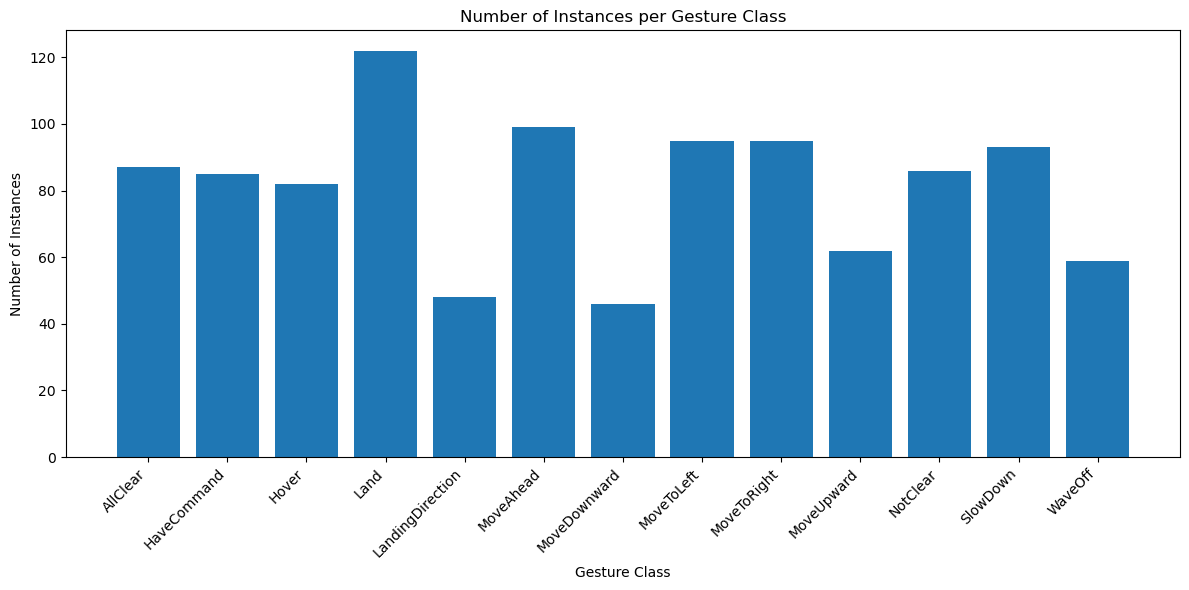

In [8]:
# plot as graph
plt.figure(figsize=(12, 6))

plt.bar(class_counts.keys(), class_counts.values())

plt.xlabel("Gesture Class")
plt.ylabel("Number of Instances")
plt.title("Number of Instances per Gesture Class")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [9]:
#Number of subjects in a particular class
CLASS_DIR = os.path.join(DATA_DIR, "MoveToRight")

print("Number of items:", len(os.listdir(CLASS_DIR)))
print("First 20 items:")

for item in os.listdir(CLASS_DIR)[:20]:
    print(item)

Number of items: 11
First 20 items:
S6
S1
S14
S12
S15
S3
S9
S5
S13
S11
S4


In [10]:
# number of instances for a subject in a particular class
SUBJECT_DIR = os.path.join(DATA_DIR, "MoveToRight", "S1")

print("Number of items:", len(os.listdir(SUBJECT_DIR)))
print("First 20 items:")

for item in os.listdir(SUBJECT_DIR)[:20]:
    print(item)

Number of items: 9
First 20 items:
Instance5
Instance7
Instance1
Instance2
Instance9
Instance3
Instance4
Instance8
Instance6


In [11]:
# check if instance has 5 images
INSTANCE_DIR = os.path.join(
    DATA_DIR,
    "MoveToRight",
    "S1",
    "Instance1"
)

print("Number of files:", len(os.listdir(INSTANCE_DIR)))
print("Files:")

for item in sorted(os.listdir(INSTANCE_DIR)):
    print(item)

Number of files: 5
Files:
S1_moveToRight_HD_instance1_1.png
S1_moveToRight_HD_instance1_2.png
S1_moveToRight_HD_instance1_3.png
S1_moveToRight_HD_instance1_4.png
S1_moveToRight_HD_instance1_5.png


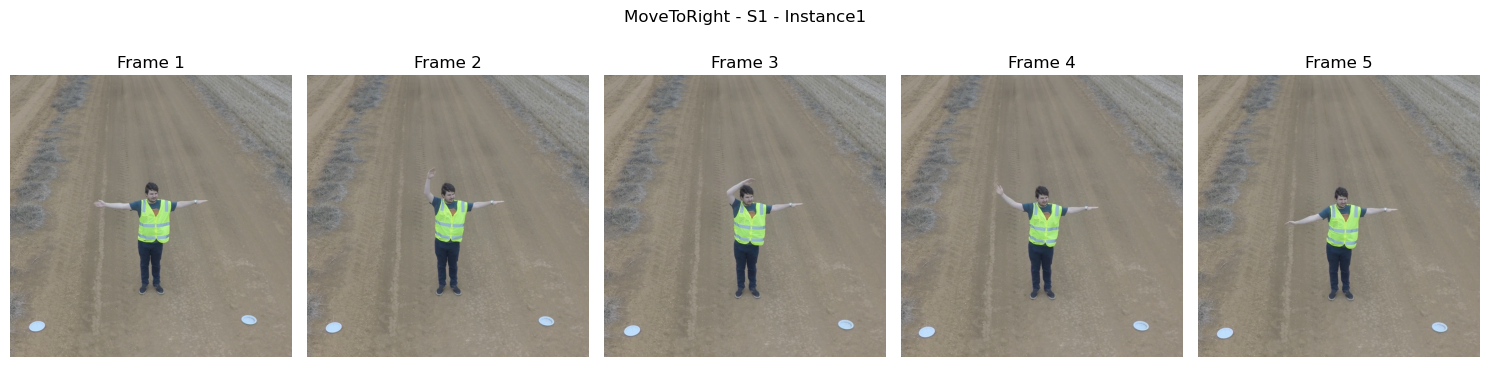

In [12]:
#Display frames from an instance as test
frame_files = sorted(os.listdir(INSTANCE_DIR))

fig, axes = plt.subplots(1, len(frame_files), figsize=(15, 4))

for i, file_name in enumerate(frame_files):
    image_path = os.path.join(INSTANCE_DIR, file_name)
    image = Image.open(image_path)

    axes[i].imshow(image)
    axes[i].set_title(f"Frame {i + 1}")
    axes[i].axis("off")

plt.suptitle("MoveToRight - S1 - Instance1")
plt.tight_layout()
plt.show()

SlowDown and Land gestures are both quite similar and the model has struggled to identify differences between them. These images show how similar these gestures are.

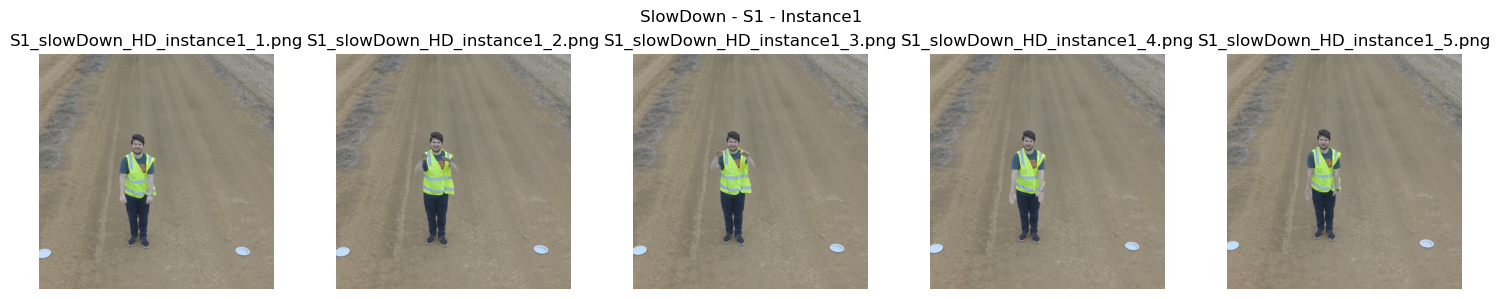

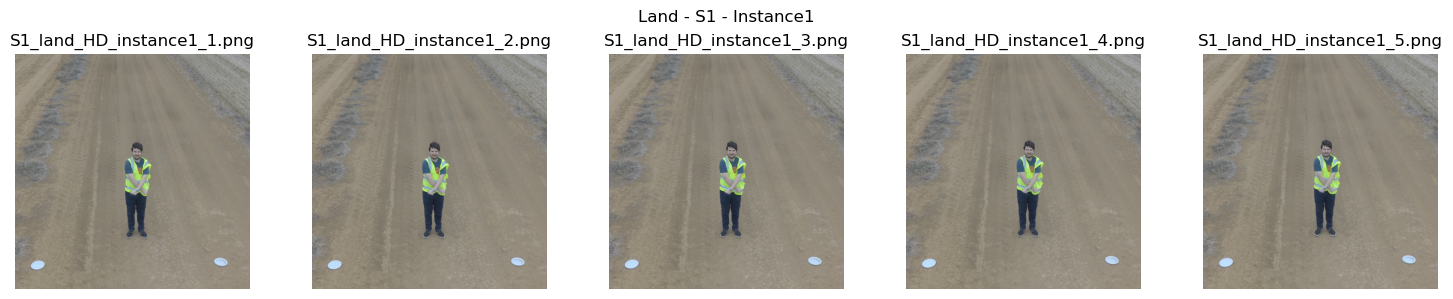

In [13]:
#compare slowdown and land frames as the model is struggling to identify between these ones.

for gesture, subject, instance in [("SlowDown", "S1", "Instance1"), ("Land", "S1", "Instance1")]:
    instance_dir = os.path.join(DATA_DIR, gesture, subject, instance)
    frame_files = sorted(os.listdir(instance_dir))

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f"{gesture} - {subject} - {instance}")
    for ax, frame_file in zip(axes, frame_files):
        img = Image.open(os.path.join(instance_dir, frame_file))
        ax.imshow(img)
        ax.set_title(frame_file)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [14]:
#Instances per subject
# Get all subjects
subjects = set()

for class_name in classes:
    class_path = DATA_DIR / class_name

    for subject_path in class_path.iterdir():
        if subject_path.is_dir():
            subjects.add(subject_path.name)

# Sort subjects numerically
subjects = sorted(subjects, key=lambda x: int(x[1:]))

subject_counts = {subject: 0 for subject in subjects}

for class_name in classes:
    class_path = DATA_DIR / class_name

    for subject_path in class_path.iterdir():
        if subject_path.is_dir():
            subject_counts[subject_path.name] += sum(
                1 for instance in subject_path.iterdir()
                if instance.is_dir()
            )


print("Number of subjects:", len(subjects))
subject_counts


Number of subjects: 11


{'S1': 119,
 'S3': 67,
 'S4': 108,
 'S5': 99,
 'S6': 114,
 'S9': 66,
 'S11': 119,
 'S12': 125,
 'S13': 115,
 'S14': 64,
 'S15': 63}

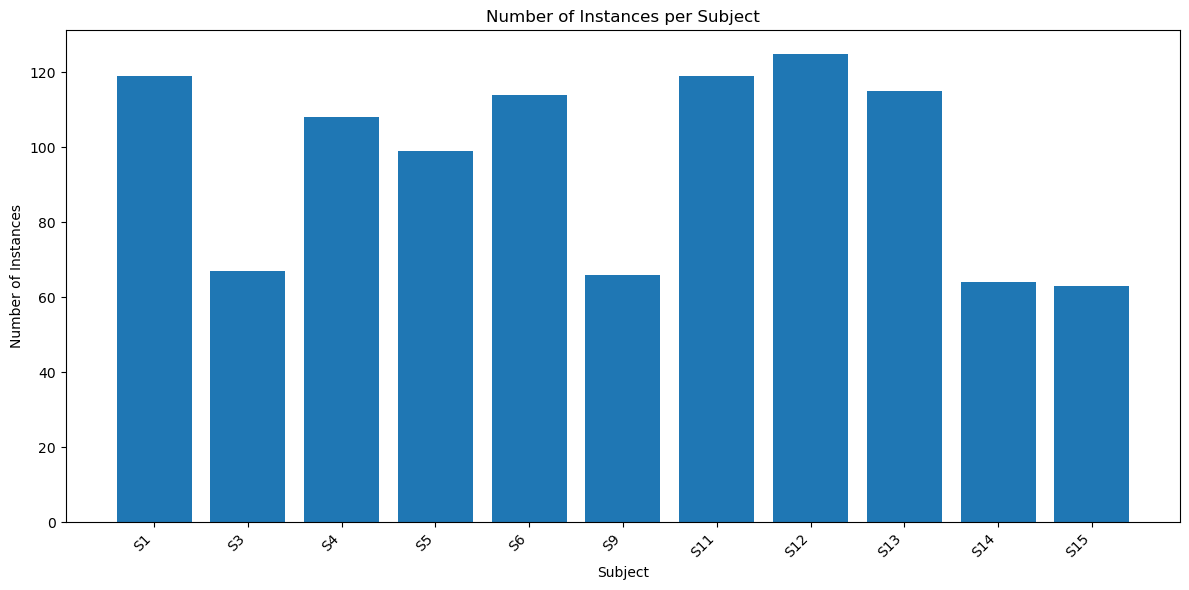

In [15]:
#plot as graph
plt.figure(figsize=(12, 6))

plt.bar(subject_counts.keys(), subject_counts.values())

plt.xlabel("Subject")
plt.ylabel("Number of Instances")
plt.title("Number of Instances per Subject")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

# Data Splitting Reasoning

The dataset was split by subject rather than randomly splitting individual gesture instances. This ensures that the subjects used for validation and testing are not observed during model training.

A random instance-level split could allow images of the same person to occur in both the training and test sets. This may cause the model to learn subject-specific characteristics, such as clothing or appearance, rather than features that generalise to the gesture itself.

A subject-independent split therefore provides a more realistic evaluation of the model's ability to recognise gestures performed by previously unseen people.

In [16]:
# Count instances for each subject and class
subject_class_counts = {}

for subject in subjects:
    subject_class_counts[subject] = {}

    for class_name in classes:
        subject_path = DATA_DIR / class_name / subject

        if subject_path.exists():
            count = sum(
                1 for instance in subject_path.iterdir()
                if instance.is_dir()
            )
        else:
            count = 0

        subject_class_counts[subject][class_name] = count

subject_class_df = pd.DataFrame(subject_class_counts).T

subject_class_df

,AllClear,HaveCommand,Hover,Land,LandingDirection,MoveAhead,MoveDownward,MoveToLeft,MoveToRight,MoveUpward,NotClear,SlowDown,WaveOff
S1,8,9,9,17,7,10,8,9,9,10,5,9,9
S3,9,10,0,0,0,10,0,10,9,0,10,9,0
S4,7,7,13,17,7,6,7,7,10,8,6,6,7
S5,6,5,16,17,4,8,6,7,6,7,6,5,6
S6,9,5,13,16,5,10,7,8,9,9,8,7,8
S9,10,9,0,0,0,10,0,10,10,0,7,10,0
S11,9,7,9,19,9,8,5,9,8,9,9,9,9
S12,8,7,11,18,8,10,8,8,9,9,7,10,12
S13,4,9,11,18,8,9,5,9,8,10,9,7,8
S14,10,8,0,0,0,8,0,9,8,0,10,11,0


In [17]:
total_instances = subject_class_df.values.sum()
total_images = total_instances * 5

print("Total number of images:", total_images)
print("Total number of instances:", total_instances)

Total number of images: 5295
Total number of instances: 1059


Eligible subjects to go into validation or test splits must have instances of every gesture. Therefore:
    Eligible: S1, S4, S5, S6, S11, S12, S13
    Ineligible: S3, S9, S14, S15

In [18]:
#Make our splits

best_split = None
best_score = float("inf")

total_instances = subject_class_df.values.sum()

for val_subjects in combinations(subjects, 2):
    remaining = [s for s in subjects if s not in val_subjects]

    for test_subjects in combinations(remaining, 2):
        train_subjects = [s for s in remaining if s not in test_subjects]

        # Check every class exists in every split
        if (
            (subject_class_df.loc[train_subjects].sum() > 0).all()
            and (subject_class_df.loc[list(val_subjects)].sum() > 0).all()
            and (subject_class_df.loc[list(test_subjects)].sum() > 0).all()
            ):
            counts = [
                subject_class_df.loc[train_subjects].values.sum(),
                subject_class_df.loc[list(val_subjects)].values.sum(),
                subject_class_df.loc[list(test_subjects)].values.sum()
            ]

            # Prefer roughly 60%, 20%, 20%
            ratios = [count / total_instances for count in counts]

            score = (
                abs(ratios[0] - 0.6)
                + abs(ratios[1] - 0.2)
                + abs(ratios[2] - 0.2)
            )

            if score < best_score:
                best_score = score
                best_split = (
                    train_subjects,
                    list(val_subjects),
                    list(test_subjects)
                )

This is how I have decided to split classes, as S4, S5, S6, and S13 all include every gesture and leave our balance close to 60/20/20 for a train/val/test split

In [19]:
train_subjects, val_subjects, test_subjects = best_split

print("Train:", train_subjects)
print("Validation:", val_subjects)
print("Test:", test_subjects)

Train: ['S1', 'S3', 'S9', 'S11', 'S12', 'S14', 'S15']
Validation: ['S4', 'S13']
Test: ['S5', 'S6']


In [20]:
print("Number of validation subjects:", len(val_subjects))
print("Number of test subjects:", len(test_subjects))

print("\nInstances:")
print("Train:", subject_class_df.loc[train_subjects].values.sum())
print("Validation:", subject_class_df.loc[val_subjects].values.sum())
print("Test:", subject_class_df.loc[test_subjects].values.sum())

Number of validation subjects: 2
Number of test subjects: 2

Instances:
Train: 623
Validation: 223
Test: 213


# Data Preprocessing


In [21]:
#Image Properties
sample_path = (DATA_DIR / "MoveToRight" / "S1" / "Instance1")

sample_file = sorted(sample_path.iterdir())[0]

image = Image.open(sample_file)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (512, 512)
Image mode: RGB


In [22]:
#convert classes to numeric labels as an index because pytorch needs numbers not strings, also provide reverse funciton if needed
class_to_idx = {
    class_name: i
    for i, class_name in enumerate(classes)
}

class_to_idx

# Reverse function
idx_to_class = {
    i: class_name
    for class_name, i in class_to_idx.items()
}

In [23]:
# Create a better index of images so pytorch can better utilise the data.

data = []

for class_name in classes:
    class_path = DATA_DIR / class_name

    for subject_path in class_path.iterdir():
        if not subject_path.is_dir():
            continue

        for instance_path in subject_path.iterdir():
            if not instance_path.is_dir():
                continue

            frames = sorted([
                frame
                for frame in instance_path.iterdir()
                if frame.is_file()
            ])

            data.append({
                "class": class_name,
                "label": class_to_idx[class_name],
                "subject": subject_path.name,
                "instance": instance_path.name,
                "frames": frames
            })

data_df = pd.DataFrame(data)

data_df.head()

,class,label,subject,instance,frames
0,AllClear,0,S6,Instance5,[../data/A1_data_2026/data_resized/AllClear/S6...
1,AllClear,0,S6,Instance7,[../data/A1_data_2026/data_resized/AllClear/S6...
2,AllClear,0,S6,Instance1,[../data/A1_data_2026/data_resized/AllClear/S6...
3,AllClear,0,S6,Instance2,[../data/A1_data_2026/data_resized/AllClear/S6...
4,AllClear,0,S6,Instance9,[../data/A1_data_2026/data_resized/AllClear/S6...


In [24]:
data_df["num_frames"] = data_df["frames"].apply(len)

data_df["num_frames"].value_counts()

num_frames
5    1059
Name: count, dtype: int64

In [25]:
# Check that there are no instances without 5 images
bad_instances = data_df[data_df["num_frames"] != 5]

print("Instances without exactly 5 frames:", len(bad_instances))

Instances without exactly 5 frames: 0


In [26]:
# Perform our data split at roughly 60/20/20 train/val/test
train_df = data_df[data_df["subject"].isin(train_subjects)].reset_index(drop=True)
val_df = data_df[data_df["subject"].isin(val_subjects)].reset_index(drop=True)
test_df = data_df[data_df["subject"].isin(test_subjects)].reset_index(drop=True)

print("Training instances:", len(train_df))
print("Validation instances:", len(val_df))
print("Testing instances:", len(test_df))

Training instances: 623
Validation instances: 223
Testing instances: 213


# Image Preproessing
All images were originally resized to 128 x 128, RandomResizedCrop was tried, but the results were slightly poorer so I moved back to a standard resize. The reason for dropping the image size was to keep computatoin requirments managable. I tried 160x160 for the final model and it performed slightly better,  the results are shown in a markdown cell at the bottom of the notebook. The training data also uses a mild colour jitter to introduce small variations in brighness, contrast, and saturation. This helped to reduce some of the overfitting due to particular lighting and colour in the training subjects.

Spatial augmentations such as random cropping and rotation were not used, beause each sequence had 5 related frames, applying these transformations independently could introduce artificial differences between the frames and intefere with the models ability to learn patters between them.

After conversion to tensors, the images are normalised using the ImageNet mean and standard deviation because the model uses an ImageNet pretrained MobileNetV2 backbone. MobileNetV2 was selected as the feature extraction backbone because it provides a good balance between classification performance and computational efficiency. Its use of depthwise separable convolutions substantially reduces the number of parameters and calculations compared with larger convolutional networks, making it suitable for training with limited computational resources. Validatoin and test images were resized and normalised without augmentation to ensure that evaluation remains consistent throughout testing.

In [74]:
# Image preprocessing
IMAGE_SIZE = 160
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform = eval_transform 

# Gesture Dataset
As required, each gesture instance is represented using all five available frames. The custom PyTorch dataset loads the ordered RGB frames, applies preprocessing, and stacks them into a single tensor alongside the numeric class label. This allows the model to use information from the complete gesture rather than classifying an individual frame.

In [75]:
# Create PyTorch Dataset
class GestureDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        frames = []

        # Load all 5 frames
        for frame_path in row["frames"]:
            image = Image.open(frame_path).convert("RGB")

            if self.transform:
                image = self.transform(image)

            frames.append(image)

        # Combine the 5 frames into one tensor
        frames = torch.stack(frames)

        # Get the correct gesture label
        label = row["label"]

        return frames, label

In [76]:
# Create Datasets
train_dataset = GestureDataset(train_df, train_transform)
val_dataset = GestureDataset(val_df, eval_transform)
test_dataset = GestureDataset(test_df, eval_transform)

In [77]:
frames, label = train_dataset[0]

print("Frames shape:", frames.shape)
print("Label:", label)
print("Class:", idx_to_class[label])

Frames shape: torch.Size([5, 3, 160, 160])
Label: 0
Class: AllClear


# DataLoaders

A batch size of 16 was selected as a balance between training efficiency and GPU memory usage. Training instances are shuffled to vary their order between epochs, while a seeded generator makes this order reproducible across complete runs. Validation and test data are not shuffled because their order does not affect evaluation. The sample batch confirms that the DataLoader produces the expected tensor and label shapes.

In [78]:
batch_size = 16
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

frames, labels = next(iter(train_loader))

print("Frames shape:", frames.shape)
print("Labels shape:", labels.shape)

Frames shape: torch.Size([16, 5, 3, 160, 160])
Labels shape: torch.Size([16])


# Baseline CNN Model

### Architecture and objective

A self-built 2-D CNN was developed to establish a baseline before introducing transfer learning. Each of the five frames is processed by the same convolutional layers, with the extracted features concatenated before classification. This allows the network to use all frames while satisfying the restriction to a modest 2-D CNN.

The number of filters increases from 32 to 128 so that deeper layers can learn more complex visual features. Batch normalisation is used to stabilise training, while max pooling and adaptive average pooling reduce the spatial dimensions. Dropout is included to limit overfitting. The final classifier combines features from all five frames and predicts one of the 13 gesture classes.

### Training strategy

The baseline was trained using weighted cross-entropy to account for differences in class frequency, with label smoothing of 0.1 as regularisation. AdamW was used with weight decay of 0.001. Training was limited to 40 epochs, with early stopping after eight epochs without improvement in validation macro-F1 in order to save time on operations. A learning-rate scheduler reduced the learning rate when validation loss stopped improving.

Only limited tuning was performed because the purpose of this model was to provide a reference point and identify weaknesses in a CNN trained from scratch. Further development was directed towards an ImageNet pretrained backbone, which was expected to be more suitable for the limited training data.

### Evaluation framework

Macro-F1 was used as the primary model-selection measure because it gives equal importance to every gesture class and exposes poor performance on less frequent classes. Accuracy, per-class precision and recall, learning curves, and the confusion matrix were also examined. The model was selected using validation macro-F1 and then evaluated on the held-out, subject-independent test set. The confusion matrix used throughout the notebook was also helpfun in identifying weak points related to images.

### Baseline results

Training stopped after nine epochs, with the best validation macro-F1 of 0.054 occurring at epoch 1. Training loss decreased from 2.6068 to 2.3922 and training accuracy increased from 8.35% to 16.21%. However, validation loss increased from 2.5474 to 3.1282, indicating that improvements on the training data did not generalise to unseen subjects.

On the test set, the baseline achieved 19.25% accuracy but only 0.047 macro-F1. The confusion matrix shows that it predicted only `Land` and `MoveUpward`. Although 32 of 33 `Land` instances were correctly classified, most other gestures were incorrectly assigned to one of these two classes. This explains why accuracy appears better than macro-F1 and demonstrates that accuracy alone would provide a misleading evaluation.

The baseline therefore failed to learn sufficiently general gesture features from the small dataset. Its poor class coverage and increasing validation loss justified moving to transfer learning with MobileNetV2, where pretrained visual features could be fine-tuned instead of being learned entirely from scratch.

In [32]:
# Baseline Model
class GestureCNN(nn.Module):
    def __init__(self, num_classes=13):
        super().__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 5, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        batch_size, num_frames, channels, height, width = x.shape

        x = x.reshape(
            batch_size * num_frames,
            channels,
            height,
            width
        )

        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = x.reshape(batch_size, 128 * num_frames)
        x = self.classifier(x)

        return x

model = GestureCNN().to(device)

frames, labels = next(iter(train_loader))

frames = frames.to(device)

outputs = model(frames)

print("Input shape:", frames.shape)
print("Output shape:", outputs.shape)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

Input shape: torch.Size([16, 5, 3, 128, 128])
Output shape: torch.Size([16, 13])


In [33]:
class_counts_train = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts_train
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" in n]
head_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" not in n]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 0.0001},
    {"params": head_params, "lr": 0.001},
], weight_decay=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

In [34]:
# Training loop with early exit
epochs = 40
patience = 8

best_val_macro_f1 = 0.0
epochs_no_improve = 0
best_model_state = None

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0
    train_correct = 0
    train_total = 0

    for frames, labels in train_loader:
        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    running_val_loss = 0
    val_correct = 0
    val_total = 0
    val_preds_epoch, val_labels_epoch = [], []          # <-- must be here, before the loop

    with torch.no_grad():
        for frames, labels in val_loader:
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

            val_preds_epoch.extend(predictions.cpu().numpy())    # <-- and these two
            val_labels_epoch.extend(labels.cpu().numpy())        #     inside the loop

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(val_loss)

    from sklearn.metrics import f1_score
    val_macro_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="macro", zero_division=0)

    improved = val_macro_f1 > best_val_macro_f1
    if improved:
        best_val_macro_f1 = val_macro_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2%} | "
        f"Val Macro-F1: {val_macro_f1:.3f}"
        + (" *" if improved else "")
    )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break

model.load_state_dict(best_model_state)
print(f"\nLoaded best model with validation macro-F1: {best_val_macro_f1:.3f}")

Epoch 1/40 | Train Loss: 2.6068 | Train Acc: 8.35% | Val Loss: 2.5474 | Val Acc: 20.18% | Val Macro-F1: 0.054 *
Epoch 2/40 | Train Loss: 2.5407 | Train Acc: 9.63% | Val Loss: 2.5492 | Val Acc: 8.07% | Val Macro-F1: 0.012
Epoch 3/40 | Train Loss: 2.4957 | Train Acc: 11.40% | Val Loss: 2.5944 | Val Acc: 8.07% | Val Macro-F1: 0.012
Epoch 4/40 | Train Loss: 2.4683 | Train Acc: 13.80% | Val Loss: 2.6902 | Val Acc: 8.07% | Val Macro-F1: 0.012
Epoch 5/40 | Train Loss: 2.4613 | Train Acc: 12.84% | Val Loss: 2.6380 | Val Acc: 8.07% | Val Macro-F1: 0.012
Epoch 6/40 | Train Loss: 2.4224 | Train Acc: 15.73% | Val Loss: 2.9417 | Val Acc: 8.07% | Val Macro-F1: 0.012
Epoch 7/40 | Train Loss: 2.4142 | Train Acc: 17.66% | Val Loss: 2.9380 | Val Acc: 5.38% | Val Macro-F1: 0.013
Epoch 8/40 | Train Loss: 2.4041 | Train Acc: 15.57% | Val Loss: 2.9380 | Val Acc: 4.48% | Val Macro-F1: 0.011
Epoch 9/40 | Train Loss: 2.3922 | Train Acc: 16.21% | Val Loss: 3.1282 | Val Acc: 7.17% | Val Macro-F1: 0.020

Early st

In [35]:
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_name = f"gesture_model_{timestamp}_valf1_{best_val_macro_f1:.3f}.pt"
checkpoint_path = os.path.join(CHECKPOINT_DIR, checkpoint_name)

torch.save({
    "model_state_dict": model.state_dict(),
    "val_macro_f1": best_val_macro_f1,
    "num_classes": len(classes),
    "num_frames": 5,
}, checkpoint_path)

print(f"Saved checkpoint to {checkpoint_path}")

Saved checkpoint to checkpoints/gesture_model_20260903_112928_valf1_0.054.pt


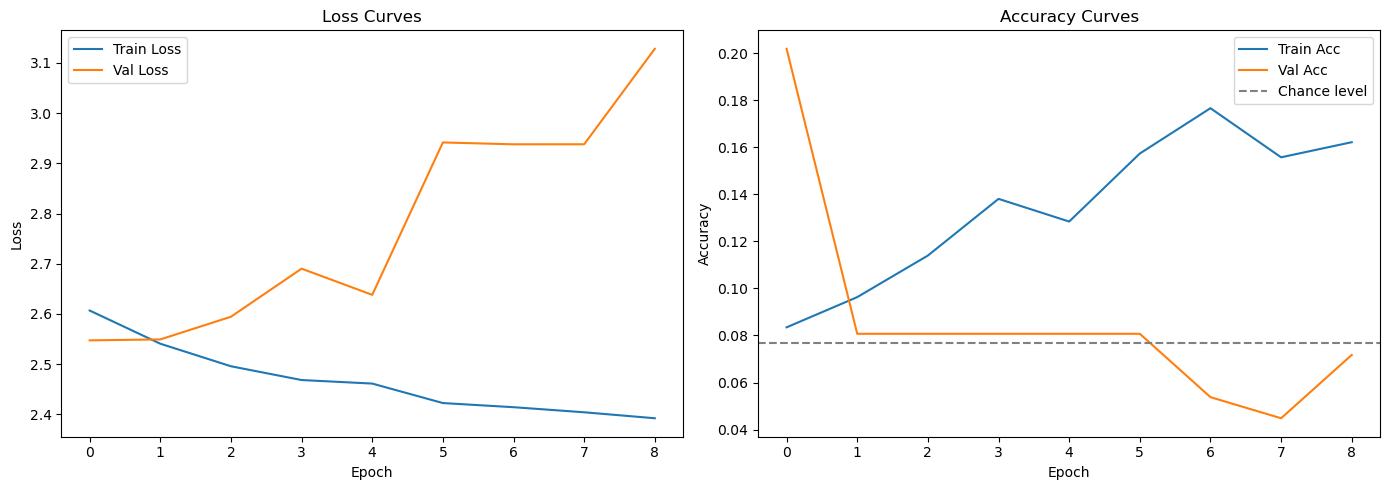

In [36]:
# Learning Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()

axes[1].plot(train_accuracies, label="Train Acc")
axes[1].plot(val_accuracies, label="Val Acc")
axes[1].axhline(1 / len(classes), color="gray", linestyle="--", label="Chance level")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curves")
axes[1].legend()

plt.tight_layout()
plt.show()

Test accuracy: 19.25%

                  precision    recall  f1-score   support

        AllClear      0.000     0.000     0.000        15
     HaveCommand      0.000     0.000     0.000        10
           Hover      0.000     0.000     0.000        29
            Land      0.193     0.970     0.322        33
LandingDirection      0.000     0.000     0.000         9
       MoveAhead      0.000     0.000     0.000        18
    MoveDownward      0.000     0.000     0.000        13
      MoveToLeft      0.000     0.000     0.000        15
     MoveToRight      0.000     0.000     0.000        15
      MoveUpward      0.191     0.562     0.286        16
        NotClear      0.000     0.000     0.000        14
        SlowDown      0.000     0.000     0.000        12
         WaveOff      0.000     0.000     0.000        14

        accuracy                          0.192       213
       macro avg      0.030     0.118     0.047       213
    weighted avg      0.044     0.192     0.071

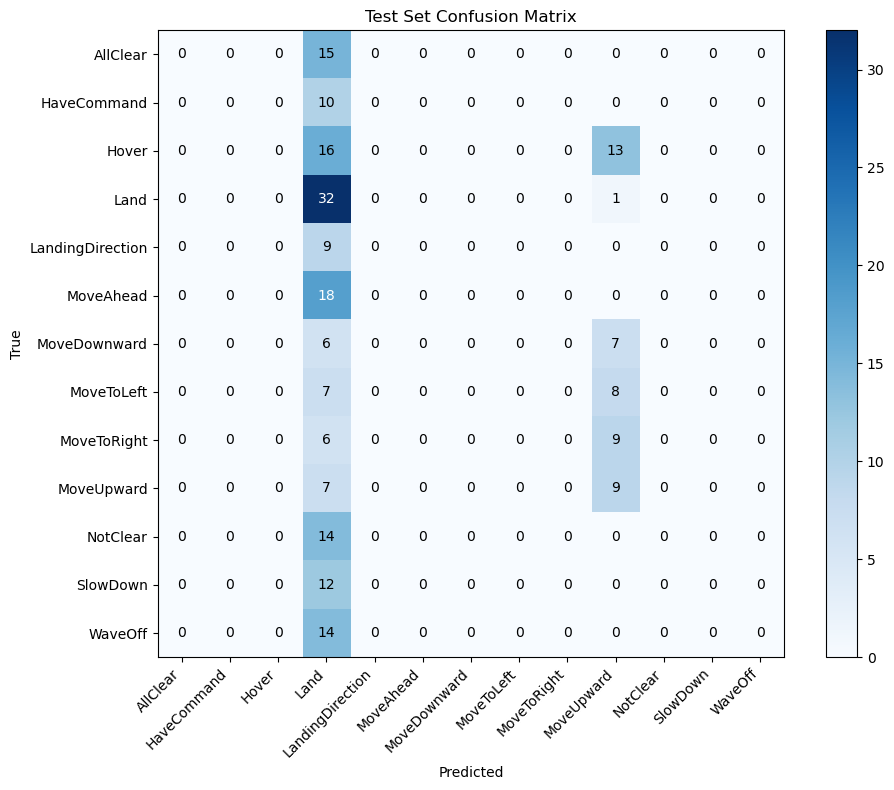

In [37]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for frames, labels in test_loader:
        frames = frames.to(device)
        outputs = model(frames)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_accuracy:.2%}\n")

print(classification_report(
    all_labels, all_preds, target_names=classes, digits=3, zero_division=0
))

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test Set Confusion Matrix")

thresh = cm.max() / 2
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

fig.colorbar(im)
plt.tight_layout()
plt.show()

# Model with Pretrain MobileNetV2 v1

The first transfer-learning model replaced the baseline feature extractor with MobileNetV2 pretrained on ImageNet. This was chosen because the dataset is relatively small, meaning that learning all visual features from scratch may be difficult. MobileNetV2 also provides a comparatively lightweight 2-D CNN backbone, making it consistent with the assignment’s computational constraints.

Only the final two backbone blocks were unfrozen initially. This conservative approach retained most of the pretrained features while allowing the later layers to begin adapting to the gesture dataset. Global average pooling reduced each frame to a compact feature vector, which was projected to 128 features. The features from all five ordered frames were then concatenated and passed through a self-built classifier. Dropout was included to reduce overfitting.

Although this model used information from all five frames, it did not explicitly represent the changes occurring between consecutive frames. It therefore provided the starting point for the next model version.


In [38]:
# model with pretrain mobilenetv2
class GestureCNNTransfer(nn.Module):
    def __init__(self, num_classes=13, num_frames=5, unfreeze_last_n_blocks=2, projected_dim=128):
        super().__init__()

        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.backbone = backbone.features          # 2-D conv trunk, output: (B, 1280, H', W')
        backbone_out_channels = 1280

        self.num_frozen_blocks = len(self.backbone) - unfreeze_last_n_blocks
        for i, block in enumerate(self.backbone):
            requires_grad = i >= self.num_frozen_blocks
            for p in block.parameters():
                p.requires_grad = requires_grad

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.project = nn.Sequential(
            nn.Linear(backbone_out_channels, projected_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )

        self.num_frames = num_frames
        self.projected_dim = projected_dim
        self.classifier = nn.Sequential(
            nn.Linear(projected_dim * num_frames, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        if mode:
            for i, block in enumerate(self.backbone):
                if i < self.num_frozen_blocks:
                    block.eval()
        return self

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.shape
        x = x.reshape(batch_size * num_frames, c, h, w)

        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        x = self.project(x)

        x = x.reshape(batch_size, num_frames * self.projected_dim)
        x = self.classifier(x)
        return x


model = GestureCNNTransfer().to(device)

frames, labels = next(iter(train_loader))
frames = frames.to(device)
outputs = model(frames)

print("Input shape:", frames.shape)
print("Output shape:", outputs.shape)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params / total_params:.1%} of total)")

Input shape: torch.Size([16, 5, 3, 128, 128])
Output shape: torch.Size([16, 13])
Total parameters:     2,471,565
Trainable parameters: 1,133,773 (45.9% of total)


In [39]:
class_counts_train = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts_train
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" in n]
head_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" not in n]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 0.0001},
    {"params": head_params, "lr": 0.001},
], weight_decay=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

In [40]:
# Training loop with early exit
epochs = 40
patience = 8

best_val_macro_f1 = 0.0
epochs_no_improve = 0
best_model_state = None

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0
    train_correct = 0
    train_total = 0

    for frames, labels in train_loader:
        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    running_val_loss = 0
    val_correct = 0
    val_total = 0
    val_preds_epoch, val_labels_epoch = [], []          # <-- must be here, before the loop

    with torch.no_grad():
        for frames, labels in val_loader:
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

            val_preds_epoch.extend(predictions.cpu().numpy())    # <-- and these two
            val_labels_epoch.extend(labels.cpu().numpy())        #     inside the loop

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(val_loss)

    from sklearn.metrics import f1_score
    val_macro_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="macro", zero_division=0)

    improved = val_macro_f1 > best_val_macro_f1
    if improved:
        best_val_macro_f1 = val_macro_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2%} | "
        f"Val Macro-F1: {val_macro_f1:.3f}"
        + (" *" if improved else "")
    )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break

model.load_state_dict(best_model_state)
print(f"\nLoaded best model with validation macro-F1: {best_val_macro_f1:.3f}")

Epoch 1/40 | Train Loss: 2.4843 | Train Acc: 17.66% | Val Loss: 2.2437 | Val Acc: 28.25% | Val Macro-F1: 0.129 *
Epoch 2/40 | Train Loss: 1.9114 | Train Acc: 36.44% | Val Loss: 2.0319 | Val Acc: 34.08% | Val Macro-F1: 0.284 *
Epoch 3/40 | Train Loss: 1.5775 | Train Acc: 50.72% | Val Loss: 2.1151 | Val Acc: 27.80% | Val Macro-F1: 0.247
Epoch 4/40 | Train Loss: 1.3713 | Train Acc: 60.67% | Val Loss: 2.0356 | Val Acc: 34.98% | Val Macro-F1: 0.283
Epoch 5/40 | Train Loss: 1.2413 | Train Acc: 66.45% | Val Loss: 2.1852 | Val Acc: 32.74% | Val Macro-F1: 0.252
Epoch 6/40 | Train Loss: 1.1163 | Train Acc: 74.64% | Val Loss: 2.3597 | Val Acc: 30.94% | Val Macro-F1: 0.274
Epoch 7/40 | Train Loss: 1.0642 | Train Acc: 78.49% | Val Loss: 2.1378 | Val Acc: 33.18% | Val Macro-F1: 0.309 *
Epoch 8/40 | Train Loss: 1.0051 | Train Acc: 85.71% | Val Loss: 2.2980 | Val Acc: 31.39% | Val Macro-F1: 0.269
Epoch 9/40 | Train Loss: 0.9480 | Train Acc: 88.92% | Val Loss: 2.3974 | Val Acc: 29.15% | Val Macro-F1: 0

# Model with Pretrain MobileNetV2 v2

V2 extended the first transfer model by explicitly including motion information. After MobileNetV2 extracts a feature vector from each frame, the model calculates the signed difference between each pair of consecutive frames. These differences are concatenated with the original frame features before classification. This allows the model to consider both the appearance of the gesture and how it changes across the five-frame sequence without using a prohibited recurrent, 3-D convolutional, or attention-based architecture.

The number of unfrozen MobileNetV2 blocks was increased from two to six to allow more of the pretrained backbone to adapt to the gesture dataset. As this increased the model’s trainable capacity and risk of overfitting, classifier dropout was increased from 0.4 to 0.5. The projection size remained at 128 so the effect of adding motion features and additional fine-tuning could be assessed without also changing the feature-vector size.

V2 retained global average pooling, which produces compact features but removes spatial information about where gestures occur within each frame. This motivated the development of V3, which retained a 2x) spatial feature map before projection.


In [41]:
#Updated model V2
class GestureCNNTransfer(nn.Module):
    def __init__(self, num_classes=13, num_frames=5, unfreeze_last_n_blocks=6, projected_dim=128):
        super().__init__()

        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.backbone = backbone.features
        backbone_out_channels = 1280

        self.num_frozen_blocks = len(self.backbone) - unfreeze_last_n_blocks
        for i, block in enumerate(self.backbone):
            requires_grad = i >= self.num_frozen_blocks
            for p in block.parameters():
                p.requires_grad = requires_grad

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.project = nn.Sequential(
            nn.Linear(backbone_out_channels, projected_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )

        self.num_frames = num_frames
        self.projected_dim = projected_dim

        classifier_in = projected_dim * num_frames + projected_dim * (num_frames - 1)
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        if mode:
            for i, block in enumerate(self.backbone):
                if i < self.num_frozen_blocks:
                    block.eval()
        return self

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.shape
        x = x.reshape(batch_size * num_frames, c, h, w)

        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        x = self.project(x)                                 
        x = x.reshape(batch_size, num_frames, self.projected_dim)  

        frame_diffs = x[:, 1:, :] - x[:, :-1, :]             

        static_feats = x.reshape(batch_size, -1)
        motion_feats = frame_diffs.reshape(batch_size, -1)

        combined = torch.cat([static_feats, motion_feats], dim=1)
        return self.classifier(combined)


model = GestureCNNTransfer().to(device)

frames, labels = next(iter(train_loader))
frames = frames.to(device)
outputs = model(frames)

print("Input shape:", frames.shape)
print("Output shape:", outputs.shape)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params / total_params:.1%} of total)")

Input shape: torch.Size([16, 5, 3, 128, 128])
Output shape: torch.Size([16, 13])
Total parameters:     2,537,101
Trainable parameters: 2,112,845 (83.3% of total)


In [42]:
class_counts_train = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts_train
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" in n]
head_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" not in n]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 0.0001},
    {"params": head_params, "lr": 0.001},
], weight_decay=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

In [43]:
# Training loop with early exit
epochs = 40
patience = 8

best_val_macro_f1 = 0.0
epochs_no_improve = 0
best_model_state = None

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0
    train_correct = 0
    train_total = 0

    for frames, labels in train_loader:
        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    running_val_loss = 0
    val_correct = 0
    val_total = 0
    val_preds_epoch, val_labels_epoch = [], []   
    with torch.no_grad():
        for frames, labels in val_loader:
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

            val_preds_epoch.extend(predictions.cpu().numpy())  
            val_labels_epoch.extend(labels.cpu().numpy())       

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(val_loss)

    from sklearn.metrics import f1_score
    val_macro_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="macro", zero_division=0)

    improved = val_macro_f1 > best_val_macro_f1
    if improved:
        best_val_macro_f1 = val_macro_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2%} | "
        f"Val Macro-F1: {val_macro_f1:.3f}"
        + (" *" if improved else "")
    )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break

model.load_state_dict(best_model_state)
print(f"\nLoaded best model with validation macro-F1: {best_val_macro_f1:.3f}")

Epoch 1/40 | Train Loss: 2.5114 | Train Acc: 17.34% | Val Loss: 2.4765 | Val Acc: 14.35% | Val Macro-F1: 0.084 *
Epoch 2/40 | Train Loss: 1.8231 | Train Acc: 43.34% | Val Loss: 2.1276 | Val Acc: 38.57% | Val Macro-F1: 0.312 *
Epoch 3/40 | Train Loss: 1.3856 | Train Acc: 62.76% | Val Loss: 1.9307 | Val Acc: 38.12% | Val Macro-F1: 0.359 *
Epoch 4/40 | Train Loss: 1.2471 | Train Acc: 67.26% | Val Loss: 2.4731 | Val Acc: 30.94% | Val Macro-F1: 0.298
Epoch 5/40 | Train Loss: 1.1162 | Train Acc: 77.05% | Val Loss: 1.9997 | Val Acc: 36.77% | Val Macro-F1: 0.360 *
Epoch 6/40 | Train Loss: 1.0747 | Train Acc: 79.45% | Val Loss: 1.9649 | Val Acc: 37.22% | Val Macro-F1: 0.322
Epoch 7/40 | Train Loss: 0.9798 | Train Acc: 87.00% | Val Loss: 2.3202 | Val Acc: 32.74% | Val Macro-F1: 0.268
Epoch 8/40 | Train Loss: 0.9260 | Train Acc: 90.05% | Val Loss: 2.1391 | Val Acc: 34.08% | Val Macro-F1: 0.305
Epoch 9/40 | Train Loss: 0.8952 | Train Acc: 93.90% | Val Loss: 2.0590 | Val Acc: 37.67% | Val Macro-F1:

# Final Model: MobileNetV2 with Spatial and Motion Features

### Architecture

The final model uses MobileNetV2 pretrained on ImageNet. This was chosen because the dataset is small, making transfer learning more practical than learning every visual feature from scratch. MobileNetV2 is also relatively lightweight, which suits the requirement for a modest 2-D CNN that could plausibly run on embedded hardware.

Each of the five frames is processed by the same backbone. The final six blocks are unfrozen for fine-tuning, while the earlier layers retain more general ImageNet features. The model has 3,028,621 parameters, of which 2,604,365 (86.0%) are trainable.

V3 retains a 2x2 feature grid for each frame, preserving some information about where visual features occur. It then calculates the difference between consecutive frame features. These motion features are combined with the original features from all five frames, allowing the classifier to use both appearance and movement information.

### Hyperparameter tuning

Models were compared primarily using validation macro-F1 because this gives equal importance to all 13 gesture classes. AdamW used a learning rate of 0.0001 for the pretrained backbone and 0.001 for the custom layers. The lower backbone rate allows the pretrained features to be adjusted gradually, while the higher rate allows the new projection and classification layers to learn more quickly.

The projection and classifier used dropout values of 0.4 and 0.6 respectively. These values were selected to provide stronger regularisation after earlier models showed a large gap between training and validation performance. However, dropout was changed alongside other architectural features, so its effect cannot be measured independently from these results. I did try 0.3 and 0.5 respectively, but the models performed slighly poorer

Weighted cross-entropy was used to account for differences in class frequency. Label smoothing of 0.1 and weight decay of 0.001 provided additional regularisation. Training was limited to 40 epochs, with early stopping after eight epochs without improvement in validation macro-F1.

Input sizes of 128 x 128 and 160 x 160 were compared using the same V3 architecture:

| Image size         | Validation macro-F1 | Test accuracy | Test macro-F1 | Weighted F1 |
| ------------------ | ------------------: | ------------: | ------------: | ----------: |
| 128 x 128 |               0.412 |        50.70% |         0.439 |       0.488 |
| 160 x 160 |           **0.448** |    **52.58%** |     **0.526** |   **0.533** |

The 160 x 160 model performed better on the main validation measure and was therefore selected, despite requiring slightly more computation.

### Model development

| Model    | Main change                              | Best validation macro-F1 |
| -------- | ---------------------------------------- | -----------------------: |
| Baseline | CNN trained from scratch                 |                    0.054 |
| V1       | Added pretrained MobileNetV2 features    |                    0.309 |
| V2       | Added consecutive-frame differences      |                    0.390 |
| V3       | Retained 2 x 2 spatial features |                **0.448** |

Transfer learning produced a clear improvement over the baseline. Adding consecutive-frame differences improved performance further, while retaining spatial information in V3 produced the strongest validation result.

### Final results

The best V3 checkpoint occurred at epoch 20, with validation accuracy of 43.95% and validation macro-F1 of 0.448. At this point, training accuracy was 97.11%. Training continued until epoch 28, when early stopping restored the epoch-20 checkpoint.

The large gap between training and validation accuracy indicates substantial overfitting. The model learned the training subjects very well but had difficulty generalising to subjects who were not present during training.

On the subject-independent test set, the final model achieved:

* Accuracy: **52.58%**
* Macro precision: **0.564**
* Macro recall: **0.542**
* Macro-F1: **0.526**
* Weighted F1: **0.533**

The strongest classes were `MoveDownward` with an F1-score of 0.769, `LandingDirection` with 0.737, `NotClear` with 0.667, and `Land` with 0.653. The weakest class was `HaveCommand`, with an F1-score of only 0.074. `SlowDown` achieved high recall of 0.917 but precision of 0.423, showing that other gestures were sometimes incorrectly predicted as `SlowDown`. If the HaveCommand class recognition could be improved, the model would perform significantly better as this gesture was predicted very poorly

V3 was selected because it achieved the highest validation macro-F1 of the tested models. However, the large training-validation gap and poor performance for some classes mean that it should be treated as a prototype. More examples from a wider range of people and conditions would be needed before the model could be considered reliable for a safety-critical application.


In [79]:
#Updated Model V3
class GestureCNNTransfer(nn.Module):
    def __init__(self, num_classes=13, num_frames=5, unfreeze_last_n_blocks=6, projected_dim=128):
        super().__init__()

        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.backbone = backbone.features
        backbone_out_channels = 1280
        pool_size = 2 

        self.num_frozen_blocks = len(self.backbone) - unfreeze_last_n_blocks
        for i, block in enumerate(self.backbone):
            requires_grad = i >= self.num_frozen_blocks
            for p in block.parameters():
                p.requires_grad = requires_grad

        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        pooled_dim = backbone_out_channels * pool_size * pool_size  # 1280 * 2 * 2 = 5120

        self.project = nn.Sequential(
            nn.Linear(pooled_dim, projected_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
        )

        self.num_frames = num_frames
        self.projected_dim = projected_dim

        classifier_in = projected_dim * num_frames + projected_dim * (num_frames - 1)
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.6),
            nn.Linear(128, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        if mode:
            for i, block in enumerate(self.backbone):
                if i < self.num_frozen_blocks:
                    block.eval()
        return self

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.shape
    
        x = x.reshape(
            batch_size * num_frames,
            c,
            h,
            w
        )
    
        x = self.backbone(x)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.project(x)
    
        x = x.reshape(
            batch_size,
            num_frames,
            self.projected_dim
        )
    
        # Differences between consecutive frame features
        frame_diffs = x[:, 1:, :] - x[:, :-1, :]
    
        static_feats = x.reshape(batch_size, -1)
        motion_feats = frame_diffs.reshape(batch_size, -1)
    
        combined = torch.cat(
            [static_feats, motion_feats],
            dim=1
        )

        return self.classifier(combined)

set_seed()
generator.manual_seed(SEED)

model = GestureCNNTransfer().to(device)

print("Input shape:", frames.shape)
print("Output shape:", outputs.shape)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params / total_params:.1%} of total)")

Input shape: torch.Size([16, 5, 3, 160, 160])
Output shape: torch.Size([16, 13])
Total parameters:     3,028,621
Trainable parameters: 2,604,365 (86.0% of total)


In [80]:
class_counts_train = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts_train
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" in n]
head_params = [p for n, p in model.named_parameters() if p.requires_grad and "backbone" not in n]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 0.0001},
    {"params": head_params, "lr": 0.001},
], weight_decay=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

In [81]:
# Training loop with early exit
epochs = 40
patience = 8

best_val_macro_f1 = 0.0
epochs_no_improve = 0
best_model_state = None

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0
    train_correct = 0
    train_total = 0

    for frames, labels in train_loader:
        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    running_val_loss = 0
    val_correct = 0
    val_total = 0
    val_preds_epoch, val_labels_epoch = [], []    

    with torch.no_grad():
        for frames, labels in val_loader:
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

            val_preds_epoch.extend(predictions.cpu().numpy())    # <-- and these two
            val_labels_epoch.extend(labels.cpu().numpy())        #     inside the loop

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(val_loss)

    from sklearn.metrics import f1_score
    val_macro_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="macro", zero_division=0)

    improved = val_macro_f1 > best_val_macro_f1
    if improved:
        best_val_macro_f1 = val_macro_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2%} | "
        f"Val Macro-F1: {val_macro_f1:.3f}"
        + (" *" if improved else "")
    )

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break

model.load_state_dict(best_model_state)
print(f"\nLoaded best model with validation macro-F1: {best_val_macro_f1:.3f}")

Epoch 1/40 | Train Loss: 2.6159 | Train Acc: 15.09% | Val Loss: 2.3564 | Val Acc: 33.18% | Val Macro-F1: 0.171 *
Epoch 2/40 | Train Loss: 2.1720 | Train Acc: 30.34% | Val Loss: 1.8014 | Val Acc: 42.15% | Val Macro-F1: 0.321 *
Epoch 3/40 | Train Loss: 1.6629 | Train Acc: 50.24% | Val Loss: 1.8224 | Val Acc: 43.95% | Val Macro-F1: 0.372 *
Epoch 4/40 | Train Loss: 1.4942 | Train Acc: 55.22% | Val Loss: 1.8905 | Val Acc: 43.05% | Val Macro-F1: 0.377 *
Epoch 5/40 | Train Loss: 1.3835 | Train Acc: 60.67% | Val Loss: 1.7907 | Val Acc: 37.22% | Val Macro-F1: 0.333
Epoch 6/40 | Train Loss: 1.2858 | Train Acc: 66.61% | Val Loss: 1.7992 | Val Acc: 42.15% | Val Macro-F1: 0.395 *
Epoch 7/40 | Train Loss: 1.1879 | Train Acc: 72.55% | Val Loss: 1.8403 | Val Acc: 41.26% | Val Macro-F1: 0.364
Epoch 8/40 | Train Loss: 1.1038 | Train Acc: 78.65% | Val Loss: 1.9601 | Val Acc: 39.01% | Val Macro-F1: 0.355
Epoch 9/40 | Train Loss: 1.0569 | Train Acc: 83.95% | Val Loss: 1.8175 | Val Acc: 36.32% | Val Macro-F

In [85]:
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  
checkpoint_name = f"gesture_model_{timestamp}_valf1_{best_val_macro_f1:.3f}.pt"
checkpoint_path = os.path.join(CHECKPOINT_DIR, checkpoint_name)

torch.save({
    "model_state_dict": model.state_dict(),
    "val_macro_f1": best_val_macro_f1,
    "unfreeze_last_n_blocks": 4,       
    "projected_dim": 128,
    "num_classes": len(classes),
    "num_frames": 5,
}, checkpoint_path)

print(f"Saved checkpoint to {checkpoint_path}")

Saved checkpoint to checkpoints/gesture_model_20260903_124029_valf1_0.448.pt


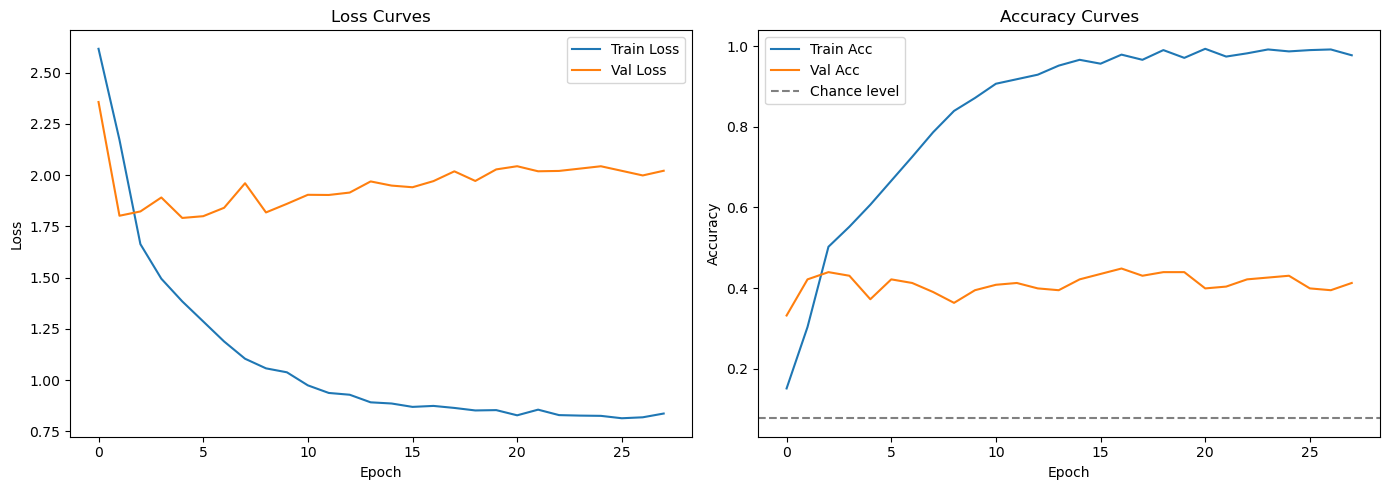

In [86]:
# Learning Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()

axes[1].plot(train_accuracies, label="Train Acc")
axes[1].plot(val_accuracies, label="Val Acc")
axes[1].axhline(1 / len(classes), color="gray", linestyle="--", label="Chance level")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curves")
axes[1].legend()

plt.tight_layout()
plt.show()

Test accuracy: 52.58%

                  precision    recall  f1-score   support

        AllClear      0.625     0.333     0.435        15
     HaveCommand      0.059     0.100     0.074        10
           Hover      0.419     0.448     0.433        29
            Land      1.000     0.485     0.653        33
LandingDirection      0.700     0.778     0.737         9
       MoveAhead      0.692     0.500     0.581        18
    MoveDownward      0.769     0.769     0.769        13
      MoveToLeft      0.389     0.467     0.424        15
     MoveToRight      0.438     0.467     0.452        15
      MoveUpward      0.562     0.562     0.562        16
        NotClear      0.545     0.857     0.667        14
        SlowDown      0.423     0.917     0.579        12
         WaveOff      0.714     0.357     0.476        14

        accuracy                          0.526       213
       macro avg      0.564     0.542     0.526       213
    weighted avg      0.601     0.526     0.533

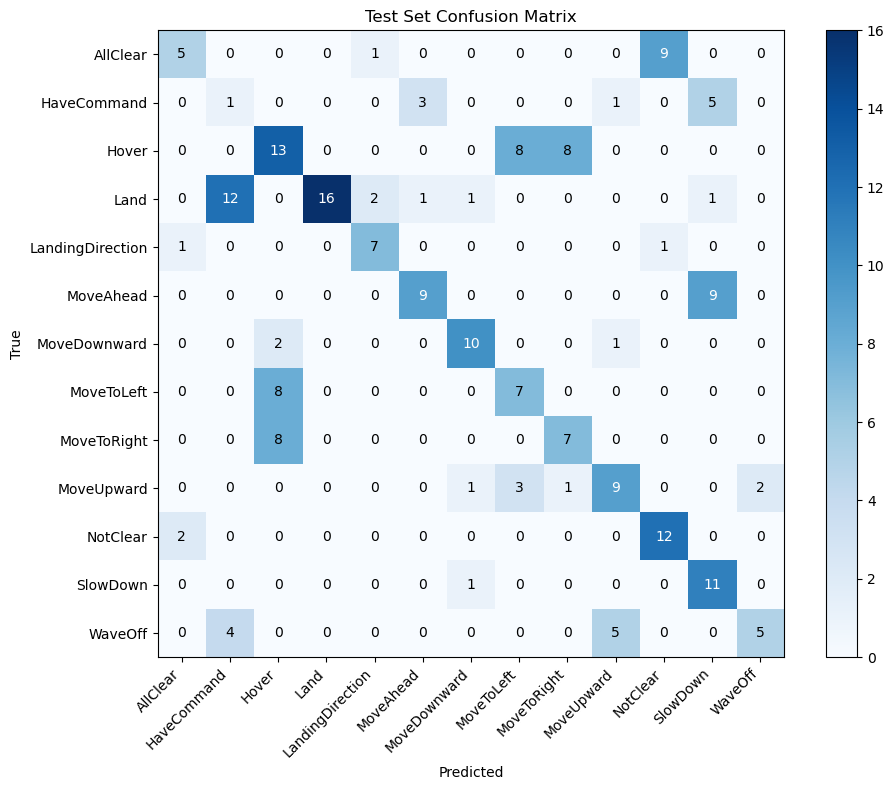

In [87]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for frames, labels in test_loader:
        frames = frames.to(device)
        outputs = model(frames)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_accuracy:.2%}\n")

print(classification_report(
    all_labels, all_preds, target_names=classes, digits=3, zero_division=0
))

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test Set Confusion Matrix")

thresh = cm.max() / 2
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

fig.colorbar(im)
plt.tight_layout()
plt.show()

RESULTS FROM 128 x 128

Epoch 1/40 | Train Loss: 2.6524 | Train Acc: 13.00% | Val Loss: 2.5245 | Val Acc: 22.42% | Val Macro-F1: 0.164 *
Epoch 2/40 | Train Loss: 2.2113 | Train Acc: 29.53% | Val Loss: 1.8092 | Val Acc: 48.43% | Val Macro-F1: 0.343 *
Epoch 3/40 | Train Loss: 1.7737 | Train Acc: 46.55% | Val Loss: 1.8818 | Val Acc: 42.15% | Val Macro-F1: 0.367 *
Epoch 4/40 | Train Loss: 1.5714 | Train Acc: 53.93% | Val Loss: 2.0073 | Val Acc: 42.60% | Val Macro-F1: 0.370 *
Epoch 5/40 | Train Loss: 1.4669 | Train Acc: 56.34% | Val Loss: 1.9139 | Val Acc: 42.60% | Val Macro-F1: 0.412 *
Epoch 6/40 | Train Loss: 1.3489 | Train Acc: 63.72% | Val Loss: 2.2648 | Val Acc: 29.15% | Val Macro-F1: 0.242
Epoch 7/40 | Train Loss: 1.3195 | Train Acc: 64.21% | Val Loss: 2.3478 | Val Acc: 29.60% | Val Macro-F1: 0.261
Epoch 8/40 | Train Loss: 1.2369 | Train Acc: 69.18% | Val Loss: 2.4581 | Val Acc: 28.70% | Val Macro-F1: 0.232
Epoch 9/40 | Train Loss: 1.1765 | Train Acc: 75.28% | Val Loss: 2.4374 | Val Acc: 26.01% | Val Macro-F1: 0.220
Epoch 10/40 | Train Loss: 1.1330 | Train Acc: 81.22% | Val Loss: 2.2015 | Val Acc: 37.67% | Val Macro-F1: 0.363
Epoch 11/40 | Train Loss: 1.1005 | Train Acc: 81.86% | Val Loss: 2.4619 | Val Acc: 33.18% | Val Macro-F1: 0.305
Epoch 12/40 | Train Loss: 1.0774 | Train Acc: 82.99% | Val Loss: 2.4018 | Val Acc: 32.29% | Val Macro-F1: 0.278
Epoch 13/40 | Train Loss: 1.0085 | Train Acc: 88.76% | Val Loss: 2.3762 | Val Acc: 32.74% | Val Macro-F1: 0.310

Early stopping triggered after 13 epochs.

Loaded best model with validation macro-F1: 0.412

Test accuracy: 50.70%

                  precision    recall  f1-score   support

        AllClear      0.500     0.933     0.651        15
     HaveCommand      0.000     0.000     0.000        10
           Hover      0.639     0.793     0.708        29
            Land      0.833     0.606     0.702        33
LandingDirection      1.000     0.444     0.615         9
       MoveAhead      0.667     0.444     0.533        18
    MoveDownward      0.786     0.846     0.815        13
      MoveToLeft      0.526     0.667     0.588        15
     MoveToRight      0.200     0.333     0.250        15
      MoveUpward      0.375     0.375     0.375        16
        NotClear      0.000     0.000     0.000        14
        SlowDown      0.167     0.333     0.222        12
         WaveOff      0.300     0.214     0.250        14

        accuracy                          0.507       213
       macro avg      0.461     0.461     0.439       213
    weighted avg      0.506     0.507     0.488       213

RESULTS FROM 160X160

Epoch 1/40 | Train Loss: 2.6159 | Train Acc: 15.09% | Val Loss: 2.3564 | Val Acc: 33.18% | Val Macro-F1: 0.171 *
Epoch 2/40 | Train Loss: 2.1720 | Train Acc: 30.34% | Val Loss: 1.8014 | Val Acc: 42.15% | Val Macro-F1: 0.321 *
Epoch 3/40 | Train Loss: 1.6629 | Train Acc: 50.24% | Val Loss: 1.8224 | Val Acc: 43.95% | Val Macro-F1: 0.372 *
Epoch 4/40 | Train Loss: 1.4942 | Train Acc: 55.22% | Val Loss: 1.8905 | Val Acc: 43.05% | Val Macro-F1: 0.377 *
Epoch 5/40 | Train Loss: 1.3835 | Train Acc: 60.67% | Val Loss: 1.7907 | Val Acc: 37.22% | Val Macro-F1: 0.333
Epoch 6/40 | Train Loss: 1.2858 | Train Acc: 66.61% | Val Loss: 1.7992 | Val Acc: 42.15% | Val Macro-F1: 0.395 *
Epoch 7/40 | Train Loss: 1.1879 | Train Acc: 72.55% | Val Loss: 1.8403 | Val Acc: 41.26% | Val Macro-F1: 0.364
Epoch 8/40 | Train Loss: 1.1038 | Train Acc: 78.65% | Val Loss: 1.9601 | Val Acc: 39.01% | Val Macro-F1: 0.355
Epoch 9/40 | Train Loss: 1.0569 | Train Acc: 83.95% | Val Loss: 1.8175 | Val Acc: 36.32% | Val Macro-F1: 0.339
Epoch 10/40 | Train Loss: 1.0376 | Train Acc: 87.16% | Val Loss: 1.8595 | Val Acc: 39.46% | Val Macro-F1: 0.378
Epoch 11/40 | Train Loss: 0.9739 | Train Acc: 90.69% | Val Loss: 1.9036 | Val Acc: 40.81% | Val Macro-F1: 0.399 *
Epoch 12/40 | Train Loss: 0.9368 | Train Acc: 91.81% | Val Loss: 1.9028 | Val Acc: 41.26% | Val Macro-F1: 0.419 *
Epoch 13/40 | Train Loss: 0.9281 | Train Acc: 92.94% | Val Loss: 1.9145 | Val Acc: 39.91% | Val Macro-F1: 0.395
Epoch 14/40 | Train Loss: 0.8911 | Train Acc: 95.18% | Val Loss: 1.9688 | Val Acc: 39.46% | Val Macro-F1: 0.385
Epoch 15/40 | Train Loss: 0.8854 | Train Acc: 96.63% | Val Loss: 1.9485 | Val Acc: 42.15% | Val Macro-F1: 0.421 *
Epoch 16/40 | Train Loss: 0.8688 | Train Acc: 95.67% | Val Loss: 1.9405 | Val Acc: 43.50% | Val Macro-F1: 0.435 *
Epoch 17/40 | Train Loss: 0.8736 | Train Acc: 97.91% | Val Loss: 1.9703 | Val Acc: 44.84% | Val Macro-F1: 0.426
Epoch 18/40 | Train Loss: 0.8637 | Train Acc: 96.63% | Val Loss: 2.0181 | Val Acc: 43.05% | Val Macro-F1: 0.404
Epoch 19/40 | Train Loss: 0.8515 | Train Acc: 99.04% | Val Loss: 1.9712 | Val Acc: 43.95% | Val Macro-F1: 0.435
Epoch 20/40 | Train Loss: 0.8531 | Train Acc: 97.11% | Val Loss: 2.0275 | Val Acc: 43.95% | Val Macro-F1: 0.448 *
Epoch 21/40 | Train Loss: 0.8277 | Train Acc: 99.36% | Val Loss: 2.0430 | Val Acc: 39.91% | Val Macro-F1: 0.390
Epoch 22/40 | Train Loss: 0.8553 | Train Acc: 97.43% | Val Loss: 2.0183 | Val Acc: 40.36% | Val Macro-F1: 0.390
Epoch 23/40 | Train Loss: 0.8287 | Train Acc: 98.23% | Val Loss: 2.0201 | Val Acc: 42.15% | Val Macro-F1: 0.411
Epoch 24/40 | Train Loss: 0.8263 | Train Acc: 99.20% | Val Loss: 2.0314 | Val Acc: 42.60% | Val Macro-F1: 0.416
Epoch 25/40 | Train Loss: 0.8251 | Train Acc: 98.72% | Val Loss: 2.0429 | Val Acc: 43.05% | Val Macro-F1: 0.415
Epoch 26/40 | Train Loss: 0.8134 | Train Acc: 99.04% | Val Loss: 2.0205 | Val Acc: 39.91% | Val Macro-F1: 0.393
Epoch 27/40 | Train Loss: 0.8180 | Train Acc: 99.20% | Val Loss: 1.9980 | Val Acc: 39.46% | Val Macro-F1: 0.392
Epoch 28/40 | Train Loss: 0.8364 | Train Acc: 97.75% | Val Loss: 2.0209 | Val Acc: 41.26% | Val Macro-F1: 0.400

Early stopping triggered after 28 epochs.

Loaded best model with validation macro-F1: 0.448

Test accuracy: 52.58%

                  precision    recall  f1-score   support

        AllClear      0.625     0.333     0.435        15
     HaveCommand      0.059     0.100     0.074        10
           Hover      0.419     0.448     0.433        29
            Land      1.000     0.485     0.653        33
LandingDirection      0.700     0.778     0.737         9
       MoveAhead      0.692     0.500     0.581        18
    MoveDownward      0.769     0.769     0.769        13
      MoveToLeft      0.389     0.467     0.424        15
     MoveToRight      0.438     0.467     0.452        15
      MoveUpward      0.562     0.562     0.562        16
        NotClear      0.545     0.857     0.667        14
        SlowDown      0.423     0.917     0.579        12
         WaveOff      0.714     0.357     0.476        14

        accuracy                          0.526       213
       macro avg      0.564     0.542     0.526       213
    weighted avg      0.601     0.526     0.533       213

In [97]:
CHECKPOINT_DIR = "checkpoints"

if os.path.exists(CHECKPOINT_DIR):
    checkpoint_files = sorted(os.listdir(CHECKPOINT_DIR))

    print(f"Found {len(checkpoint_files)} checkpoint(s):\n")

    for filename in checkpoint_files:
        if filename.endswith(".pt"):
            print(filename)
else:
    print("No checkpoints directory found.")


Found 38 checkpoint(s):

gesture_model_20260902_084448_valf1_0.082.pt
gesture_model_20260902_094104_valf1_0.056.pt
gesture_model_20260902_095142_valf1_0.363.pt
gesture_model_20260902_100654_valf1_0.411.pt
gesture_model_20260902_104320_valf1_0.099.pt
gesture_model_20260902_113309_valf1_0.419.pt
gesture_model_20260902_131053_valf1_0.096.pt
gesture_model_20260902_154239_valf1_0.131.pt
gesture_model_20260902_155733_valf1_0.317.pt
gesture_model_20260902_162650_valf1_0.131.pt
gesture_model_20260902_165109_valf1_0.131.pt
gesture_model_20260902_171009_valf1_0.426.pt
gesture_model_20260902_174442_valf1_0.131.pt
gesture_model_20260902_180337_valf1_0.426.pt
gesture_model_20260902_185952_valf1_0.098.pt
gesture_model_20260902_193222_valf1_0.293.pt
gesture_model_20260903_022859_valf1_0.347.pt
gesture_model_20260903_025148_valf1_0.098.pt
gesture_model_20260903_035930_valf1_0.098.pt
gesture_model_20260903_050337_valf1_0.131.pt
gesture_model_20260903_052247_valf1_0.426.pt
gesture_model_20260903_060154_

# Part B — Executive Recommendation

I think that it would be very risky to deply the model as-is, due to how unreliable the predictions are and how important dealing with medical supplies in a time critical fashion. More time would be needed to develop the model. But if it was to be deployed as is there are several key points to be noted about the risks.

* **Do not deploy the model as-is.** On the subject-independent test set it correctly classified 52.58% of gestures, meaning almost half were interpreted incorrectly. This is not adequate for a system controlling a drone near people and medical supplies.

* **Performance is not reliable across commands.** `MoveDownward` performed reasonably well with an F1-score of 0.769, but `HaveCommand` scored only 0.074 and was correctly identified once in ten test examples. Several `Land` gestures were also incorrectly classified as `HaveCommand`. An error between these commands could cause the drone to act when it should not.

* **The model does not yet generalise reliably to new people.** At the selected checkpoint, training accuracy was 97.11%, while validation accuracy was only 43.95%. This large gap shows that the model learned the training subjects much better than unseen subjects.

* **The available evidence is too limited for a safety decision.** The dataset contains only 11 people, with the final test based on two unseen subjects and 213 gesture instances. This does not cover the range of people, clothing, lighting, backgrounds, camera positions and weather conditions expected in operation.

* **More representative data and independent testing are required.** Further training should include a larger and more diverse group of participants in realistic landing-zone conditions. A new test set must then be kept separate from model development, with minimum recall requirements set for every safety-critical command rather than relying on overall accuracy.

* **The drone should fail safely when the prediction is uncertain.** The model should be able to reject a gesture instead of always selecting one of the 13 classes. An uncertain or conflicting command should place the drone into a safe state, such as holding position, rather than triggering movement.

* **Onboard performance still needs to be demonstrated.** MobileNetV2 is relatively lightweight and the final model contains approximately 3.03 million parameters, but inference speed, memory use and power consumption were not measured on the target embedded board. These must be tested using complete five-frame instances before real-time suitability can be confirmed.

* **Deployment should only follow a controlled trial and safety review.** Testing should begin in a restricted environment without people or critical payloads. Predictions, confidence scores and failures should be logged, and responsibility for approving model updates and responding to incidents should be clearly assigned before operational use.
